# 1. Import thư viện

In [28]:

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
from pathlib import Path

# 2. Xác định đường dẫn repository và checkpoint và đưa mô hình về chế độ eval

In [ ]:
import torch
import torch.nn as nn
from pathlib import Path

# 1. Định nghĩa lại NeuralNetwork khớp CHÍNH XÁC cấu trúc lúc train (784 -> 128 -> 64 -> 10)
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(28 * 28, 128),  # Tầng 1: 784 -> 128
            nn.ReLU(),
            nn.Linear(128, 64),       # Tầng 2: 128 -> 64
            nn.ReLU(),
            nn.Linear(64, 10)         # Tầng 3: 64 -> 10
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.network(x)
        return logits

# 2. Khởi tạo mô hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NeuralNetwork().to(device)

# 3. Đường dẫn checkpoint
CHECKPOINT_PATH = Path("../models/fashion_mnist_mlp_trained.pth")

# 4. Load checkpoint
if CHECKPOINT_PATH.exists():
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
    print(f"Đã load checkpoint thành công từ:\n{CHECKPOINT_PATH.resolve()}")
else:
    print(f"Chưa tìm thấy file tại: {CHECKPOINT_PATH.resolve()}")

# 5. Đưa mô hình về chế độ eval
model.eval()

🎉 Đã load checkpoint thành công từ:
Q:\Học sâu\UTH-Deep-Learning-nhom2\Practice_1\models\fashion_mnist_mlp_trained.pth


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

# 7. Tính Test Loss, Tính Test Accuracy, Lấy predicted labels


In [30]:

criterion = nn.CrossEntropyLoss()
test_loss = 0.0
correct = 0
total = 0

all_preds = []
all_labels = []
misclassified_images = []
misclassified_preds = []
misclassified_labels = []
correct_images = []
correct_preds = []

# Tắt tính toán gradient để tiết kiệm bộ nhớ và tăng tốc độ
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        # Dự đoán
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Lưu kết quả
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        # Phân loại ảnh đúng/sai để vẽ đồ thị
        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                misclassified_images.append(images[i].cpu())
                misclassified_preds.append(predicted[i].item())
                misclassified_labels.append(labels[i].item())
            else:
                correct_images.append(images[i].cpu())
                correct_preds.append(predicted[i].item())

# Tính trung bình Loss và phần trăm Accuracy
test_loss = test_loss / len(test_loader)
test_accuracy = 100 * correct / total

print(f"Tổng kết đánh giá trên tập Test:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Tổng kết đánh giá trên tập Test:
Test Loss: 0.3331
Test Accuracy: 88.50%


# 10. Hiển thị Predicted vs Actual (Các mẫu đoán đúng)

----------------------------------------
 THỐNG KÊ KẾT QUẢ DỰ ĐOÁN:
  - Tổng số mẫu đánh giá : 10000
  - Tổng số dự đoán ĐÚNG : 8850 (88.50%)
  - Tổng số dự đoán SAI  : 1150 (11.50%)
----------------------------------------



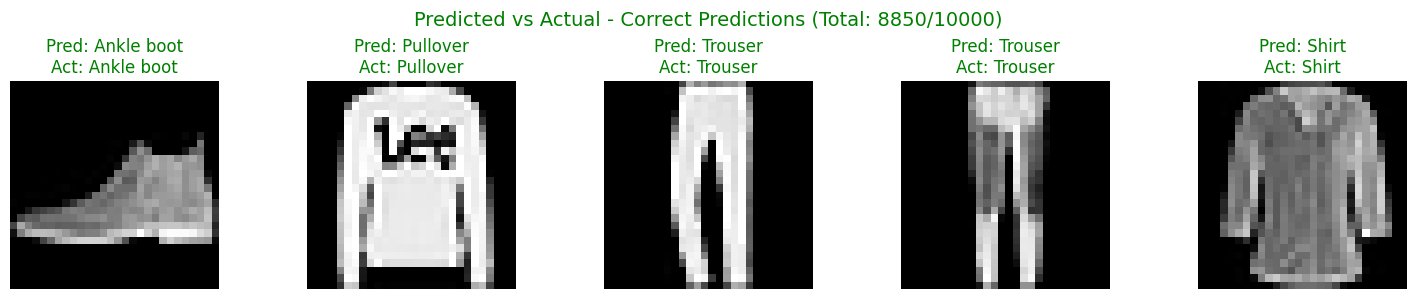

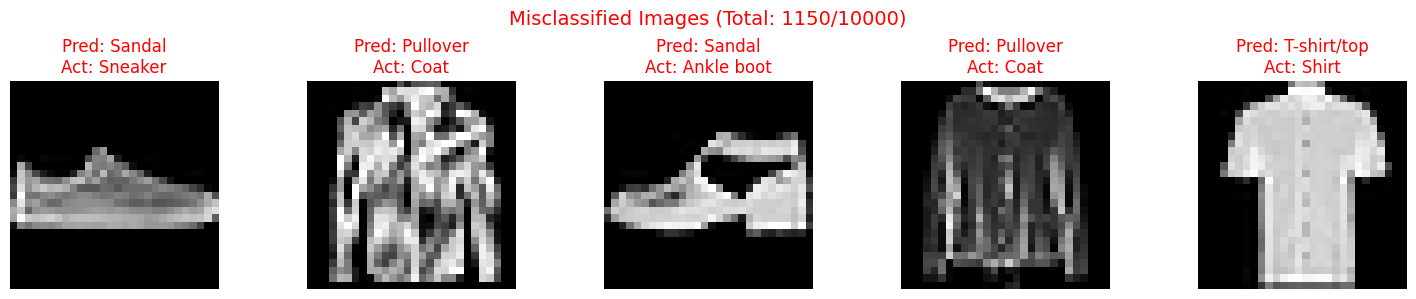

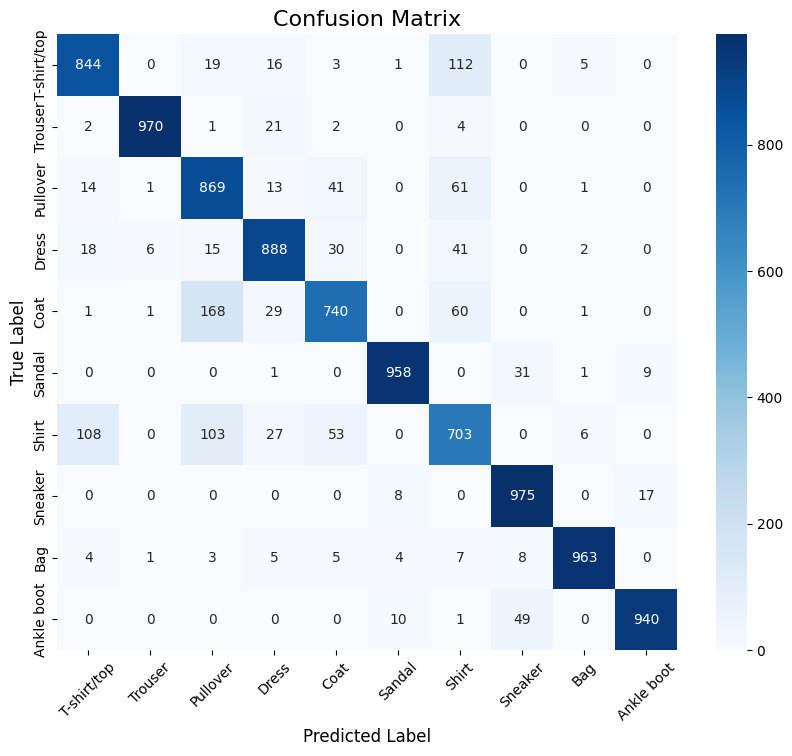

In [33]:
import numpy as np

# --- Tính toán tổng số lượng ---
total_correct = len(correct_images)
total_misclassified = len(misclassified_images)
total_samples = total_correct + total_misclassified
accuracy = (total_correct / total_samples) * 100

# In tóm tắt ra màn hình
print("-" * 40)
print(f" THỐNG KÊ KẾT QUẢ DỰ ĐOÁN:")
print(f"  - Tổng số mẫu đánh giá : {total_samples}")
print(f"  - Tổng số dự đoán ĐÚNG : {total_correct} ({accuracy:.2f}%)")
print(f"  - Tổng số dự đoán SAI  : {total_misclassified} ({100 - accuracy:.2f}%)")
print("-" * 40 + "\n")

# 10. Hiển thị một số dự đoán đúng (Kèm tổng số lượng trên tiêu đề)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle(f'Predicted vs Actual - Correct Predictions (Total: {total_correct}/{total_samples})', fontsize=14, color='green')
for i in range(min(5, total_correct)):
    ax = axes[i]
    ax.imshow(correct_images[i].squeeze(), cmap="gray")
    ax.set_title(f"Pred: {class_names[correct_preds[i]]}\nAct: {class_names[correct_preds[i]]}", color="green")
    ax.axis('off')
plt.tight_layout()
plt.show()

# 11. Hiển thị một số dự đoán sai (Kèm tổng số lượng trên tiêu đề)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle(f'Misclassified Images (Total: {total_misclassified}/{total_samples})', fontsize=14, color='red')
for i in range(min(5, total_misclassified)):
    ax = axes[i]
    ax.imshow(misclassified_images[i].squeeze(), cmap="gray")
    ax.set_title(f"Pred: {class_names[misclassified_preds[i]]}\nAct: {class_names[misclassified_labels[i]]}", color="red")
    ax.axis('off')
plt.tight_layout()
plt.show()

# 12. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=16)
plt.xticks(rotation=45)
plt.show()

13. Nhận xét kết quả

Hiệu suất tổng quan: Đánh giá mức độ chính xác (Accuracy) đạt được trên tập test. Accuracy cao (> 85%), mô hình đã học được các đặc trưng cơ bản của bộ dữ liệu FashionMNIST.

Chi tiết qua Confusion Matrix: Dựa vào ma trận nhầm lẫn, có thể thấy mô hình thường dự đoán rất tốt các lớp có hình dáng rõ ràng như Trouser (Quần dài) hay Bag (Túi xách).

Nhận định lỗi sai: Mô hình thường bị nhầm lẫn giữa các lớp có đặc điểm nhận dạng tương đồng nhau như Shirt (Áo sơ mi), T-shirt/top (Áo thun) và Coat (Áo khoác). Điều này hoàn toàn dễ hiểu với một kiến trúc mạng nơ-ron kết nối đầy đủ (Fully Connected) đơn giản vì nó gặp khó khăn trong việc nắm bắt các đặc trưng không gian (spatial features) phức tạp.

14. Summary

Quá trình xây dựng một quy trình học sâu (Deep Learning pipeline) hoàn chỉnh đã được thực hiện: từ việc load dữ liệu FashionMNIST, tiền xử lý bằng DataLoader, xây dựng mạng NeuralNetwork, cho đến việc load trọng số và đánh giá.

Việc chuyển mô hình sang trạng thái model.eval() và vô hiệu hóa gradient torch.no_grad() là bước bắt buộc để đảm bảo tốc độ và tính toán chính xác trong khâu inference (suy luận).

Việc phân tích trực quan qua ảnh và ma trận nhầm lẫn giúp định hướng rõ ràng cho các bước tối ưu tiếp theo (chẳng hạn như đổi sang dùng kiến trúc CNN để cải thiện khả năng phân loại các item quần áo giống nhau).